In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import json
from matplotlib.pyplot import text

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


matplotlib.rcParams['font.size'] = 18
# matplotlib.rcParams['font.size'] = 16ho

import re
import time
import subprocess
import os
import signal


In [27]:
import sys
sys.path.append('./helpers')

In [28]:
import importlib
from backend_helpers import *
from kernel_metrics import *
from benchmark_data import *
from visualisation import *



In [22]:
%load_ext autoreload
%autoreload 2

# Pre-flight checks

In [5]:
backend_endpoint ="127.0.0.1:5000"

In [6]:
run_host_script(script="setup_patch_clean_cfs.sh")

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 1466379.606507
sched_clk                               : 1466441.758776
cpu_clk                                 : 1466385.483338
jiffies                                 : 4296133511
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 2605714
  .nr_uninterruptible            : 57
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_l

In [7]:
run_host_script(script="setup_patch_clean_systemd_cgroupv2.sh")

kernel.sched_disable_calc_group_shares = 1
kernel.sched_disable_vruntime_preemption = 1
kernel.sched_disable_entity_eligible = 1
-----
kernel.sched_entity_before_policy = 1
kernel.sched_check_preempt_wakeup_latency_awareness = 100
kernel.sched_cpu_has_higher_load_task = 100
-----
kernel.sched_tg_load_avg_ema = 1
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/*/cpu.weight
/sys/fs/cgroup/*/*/cpu.weight
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/*/cpu.latency_awareness
/sys/fs/cgroup/*/*/cpu.latency_awareness
0
0
-----
setting latency awawreness flags
/sys/fs/cgroup/faas.slice/*/cpu.latency_awareness
1
--------



In [8]:
reset_shares_cfs()
# reset_shares_llf_static()

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 1466960.400522
sched_clk                               : 1467022.552742
cpu_clk                                 : 1466966.277262
jiffies                                 : 4296134092
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 2607651
  .nr_uninterruptible            : 57
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_l

# Kernel metrics

In [9]:
    
a = schedstat_domains_snapshot()
time.sleep(10)
b = schedstat_domains_snapshot()

(b.astype(int) - a.astype(int)).sum(axis=1)


0       143
1       143
2         0
3         0
4         0
5         0
6         0
7       143
8     12723
9     12689
10       27
11       36
12       13
13        0
14        0
15    12688
16     2729
17     2713
18       14
19       16
20        2
21        0
22        0
23     2660
24        4
25        0
26        4
27        0
28        0
29        0
30        0
31        0
32        0
33     2295
34      330
35        0
dtype: int64

In [10]:

a = schedstat_snapshot()
b = schedstat_snapshot()

display((b.astype(int) - a.astype(int)).sum())

nr_switches_start = nr_switches_snapshot()

# time.sleep(10)
nr_switches_end = nr_switches_snapshot()

display((nr_switches_end - nr_switches_start).sum())
    

yield                        103
schedule                    3276
idle                        1566
try_to_wake_up              1573
try_to_wake_up local        1285
tasks_running           61410331
tasks_waiting             344008
timeslices                  1585
dtype: int64

nr_switches    1507
dtype: int64

# Preparing files

In [33]:

    
rd_hashd_benchmark_args_workload(workload='none',functions=400)    

['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-994",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-995",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-996",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-997",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-998",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-999",', '']


# Parameter space

In [16]:
!cat /local/scratch/CFS-LLF_main/rd-hashd/params.json | grep '\/\/'

# //
# // rd-hashd runtime parameters
# //
# // All parameters can be updated while running and will be applied immediately.
# //
# // rd-hashd keeps calculating SHA1s of different parts of testfiles using
# // concurrent worker threads. The testfile indices and hash sizes are
# // determined using truncated normal distributions which gradually transforms
# // to uniform distributions as their standard deviations increase.
# //
# // All durations are in seconds and memory bytes. A _frac field should be <=
# // 1.0 and specifies a sub-proportion of some other value. A _ratio field is
# // similar but may be greater than 1.0.
# //
# // The concurrency level is modulated using two PID controllers to target the
# // specified latency and RPS so that neither is exceeded. The total number
# // of concurrent threads is limited by `concurrency_max`.
# //
# // The total size of testfiles is set up during startup and can't be changed
# // online. However, the portion which is actively used by rd

## Parameter space - independent values

In [17]:
!cat /local/scratch/CFS-LLF_main/rd-hashd/params.json  | grep -v '\/\/\|lat_target\|sleep\|concurrency'

{
  "control_period": 1.0,
  "rps_target": 65536,
  "rps_max": 1000,
  "mem_frac": 0.001,
  "chunk_pages": 25,
  "file_frac": 0.25,
  "file_size_mean": 377487,
  "file_size_stdev_ratio": 0.45,
  "file_addr_stdev_ratio": 0.215,
  "file_addr_rps_base_frac": 0.5,
  "file_write_frac": 0.0,
  "anon_size_ratio": 2.3,
  "anon_size_stdev_ratio": 0.45,
  "anon_addr_stdev_ratio": 0.235,
  "anon_addr_rps_base_frac": 0.5,
  "anon_write_frac": 0.3,
  "cpu_ratio": 0.93,
  "log_bps": 1100794,
  "fake_cpu_load": false,
  "acc_dist_slots": 0,
  "lat_pid": {
    "kp": 0.1,
    "ki": 0.01,
    "kd": 0.01
  },
  "rps_pid": {
    "kp": 0.25,
    "ki": 0.01,
    "kd": 0.01
  }
}


## Parameter space - tuned values

In [18]:
!cat /local/scratch/CFS-LLF_main/rd-hashd/params.json  | grep 'lat_target\|sleep\|concurrency'

# // The concurrency level is modulated using two PID controllers to target the
# // of concurrent threads is limited by `concurrency_max`.
# // Worker threads will sleep according to the sleep duration distribution and
# //  concurrency_max: Maximum number of worker threads
# //  lat_target_pct: Latency target percentile
# //  lat_target: Latency target
# //  sleep_mean: Worker sleep duration average
# //  sleep_stdev_ratio: Standard deviation of sleep duration distribution
  "concurrency_max": 65536,
  "lat_target_pct": 0.5,
  "lat_target": 0.1,
  "sleep_mean": 0.02,
  "sleep_stdev_ratio": 0.33,


# Experiment code

In [11]:

    
enable_schedstats()    

kernel.sched_schedstats = 1



# Results (no special kernel metrics)

In [12]:
density_range = [x for x in range(12, 12*20, 12*4)]


In [13]:
density_range = [12, 120, 228]
results_resctl_eevdf = {}
results_resctl_eevdfllf = {}

In [14]:
density_range = [12, 120,228]


In [15]:
!sudo cp ../rd-hashd/rd-hashd /usr/local/bin/rd-hashd

print(density_range)

for x in density_range: 
    results_resctl_eevdf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_eevdf.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


print(density_range)

for x in density_range: 
    results_resctl_eevdfllf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_systemd.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False!sudo cp ../rd-hashd/rd-hashd /usr/local/bin/rd-hashd

print(density_range)

for x in density_range: 
    results_resctl_eevdf_tuned[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_eevdf_tuned.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False))

    

[12, 120, 228]
vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 1484884.845785
sched_clk                               : 1484946.997285
cpu_clk                                 : 1484890.721880
jiffies                                 : 4296152016
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 2611079
  .nr_uninterruptible            : 61
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
ke

nr_switches    5816937
dtype: int64

yield                          1472655
schedule                       7126841
idle                              2192
try_to_wake_up                 2298249
try_to_wake_up local           1934716
tasks_running            3203337653288
tasks_waiting           11460398091545
timeslices                     5827822
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 1602780.649390
sched_clk                               : 1602842.795321
cpu_clk                                 : 1602786.519897
jiffies                                 : 4296269912
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 2739875
  .nr_uninterruptible            : 109
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_

nr_switches    6842783
dtype: int64

...

nr_switches    2241848
dtype: int64

yield                          1384480
schedule                       3331510
idle                               426
try_to_wake_up                  885226
try_to_wake_up local            716040
tasks_running            3206732321190
tasks_waiting           28980065368724
timeslices                     2242451
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 2120474.377711
sched_clk                               : 2120536.499438
cpu_clk                                 : 2120480.223969
jiffies                                 : 4296787606
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 3517689
  .nr_uninterruptible            : -21
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_

nr_switches    1992353
dtype: int64

yield                          1354560
schedule                       3144362
idle                               560
try_to_wake_up                  769009
try_to_wake_up local            677729
tasks_running            3210564298914
tasks_waiting           38324084181852
timeslices                     1994391
dtype: int64

In [16]:
!mkdir pickled-new

In [17]:
sort_dict_by_keys = lambda d: {key: d[key] for key in sorted(d)}

In [18]:
import pickle

def dump_vars(experiments):
    
    for key,val in experiments:
        print(key)
        file_dump = open(f'pickled-new/{key}', 'wb')
        pickle.dump(val, file_dump)
        file_dump.close()

In [19]:
variables = [
    ('results_resctl_eevdf',results_resctl_eevdf),
    ('results_resctl_eevdfllf',results_resctl_eevdfllf),
]

dump_vars(variables)


results_resctl_eevdf
results_resctl_eevdfllf


101.03 183.01
101.03 183.01
67.02 375.81199999999956
101.03 183.01
104.32 476.8660000000003
38.01 895.2139999999997
101.03 183.01
122.83500000000001 931.9789999999997
36.52 1198.4444999999998


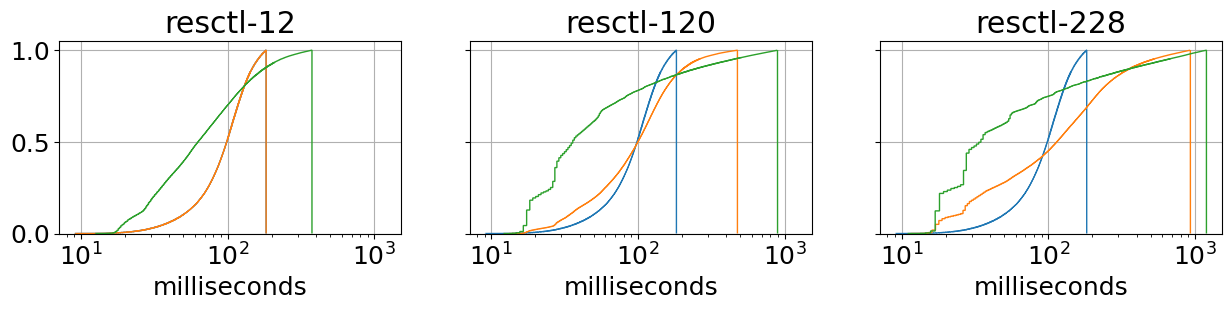

In [29]:
fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_resctl_eevdf, results_resctl_eevdfllf,fig,ax[0],'resctl-12',12,density=1)
visualise_latency_cdf(results_resctl_eevdf, results_resctl_eevdfllf,fig,ax[1],'resctl-120',120,density=1)
visualise_latency_cdf(results_resctl_eevdf, results_resctl_eevdfllf,fig,ax[2],'resctl-228',228,density=1)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,30000)



In [32]:
density_range = [12, 120, 228]
results_resctl_eevdf_tuned = {}

In [31]:
!diff --color ./../scripts/setup_patch_clean_eevdf.sh ./../scripts/setup_patch_clean_eevdf_tuned.sh 

6c6
< echo '3000000' | sudo tee -a /sys/kernel/debug/sched/base_slice_ns
---
> echo '100000000' | sudo tee -a /sys/kernel/debug/sched/base_slice_ns


In [33]:
!sudo cp ../rd-hashd/rd-hashd /usr/local/bin/rd-hashd

print(density_range)

for x in density_range: 
    results_resctl_eevdf_tuned[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_eevdf_tuned.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)

[12, 120, 228]
vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 2464368.448803
sched_clk                               : 2464430.554654
cpu_clk                                 : 2464374.279240
jiffies                                 : 4297131500
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 3766419
  .nr_uninterruptible            : -33
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
k

nr_switches    3136250
dtype: int64

yield                           914308
schedule                       3958628
idle                               658
try_to_wake_up                 1314400
try_to_wake_up local           1047792
tasks_running            3201536269999
tasks_waiting           14436286914500
timeslices                     3148530
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 2582669.201787
sched_clk                               : 2582731.302090
cpu_clk                                 : 2582675.026674
jiffies                                 : 4297249801
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 100.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 3855630
  .nr_uninterruptible            : -36
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_t

nr_switches    8118904
dtype: int64

yield                          1630493
schedule                       9347879
idle                              1076
try_to_wake_up                 4016967
try_to_wake_up local           3497584
tasks_running            3204596977999
tasks_waiting           35136537911700
timeslices                     8118845
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 2711196.977591
sched_clk                               : 2711259.071928
cpu_clk                                 : 2711202.796502
jiffies                                 : 4297378328
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 100.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 4123226
  .nr_uninterruptible            : -78
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_t

nr_switches    4629008
dtype: int64

yield                          1697116
schedule                       5891731
idle                               887
try_to_wake_up                 2125340
try_to_wake_up local           1850494
tasks_running            3205868914267
tasks_waiting           52428943668992
timeslices                     4629006
dtype: int64

In [34]:
variables = [
    ('results_resctl_eevdf_tuned',results_resctl_eevdf_tuned),
]

dump_vars(variables)


results_resctl_eevdf_tuned


99.21 232.1619999999998
99.21 232.1619999999998
67.02 375.81199999999956
99.21 232.1619999999998
88.75 630.0579999999993
38.01 895.2139999999997
99.21 232.1619999999998
63.29 950.0379999999993
36.52 1198.4444999999998


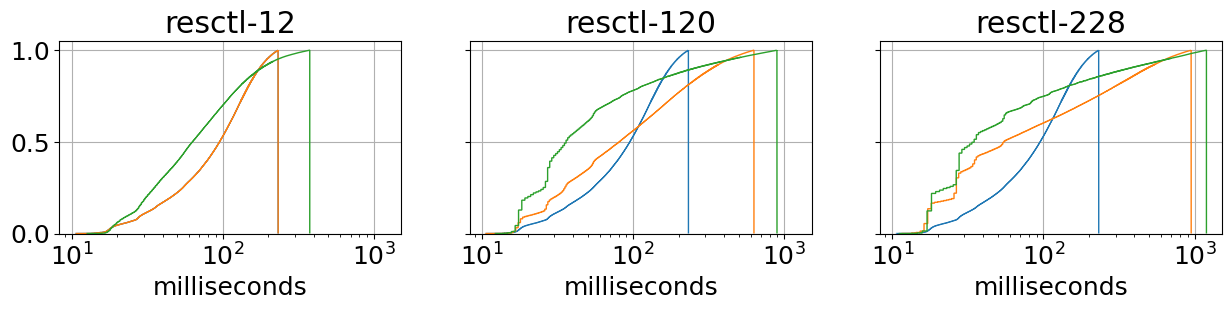

In [36]:


fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_resctl_eevdf_tuned, results_resctl_eevdfllf,fig,ax[0],'resctl-12',12,density=1)
visualise_latency_cdf(results_resctl_eevdf_tuned, results_resctl_eevdfllf,fig,ax[1],'resctl-120',120,density=1)
visualise_latency_cdf(results_resctl_eevdf_tuned, results_resctl_eevdfllf,fig,ax[2],'resctl-228',228,density=1)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,30000)



# Resctl parallel

In [49]:
density_range = [12, 120, 228]


In [50]:
results_resctlparallel_eevdf = {}
results_resctlparallel_eevdf_tuned = {}
results_resctlparallel_eevdfllf = {}

In [51]:
!sudo cp ../rd-hashd/rd-hashd-parallel /usr/local/bin/rd-hashd


print(density_range)

for x in density_range: 
    results_resctlparallel_eevdf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_eevdf.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)



print(density_range)
for x in density_range: 
    results_resctlparallel_eevdfllf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_systemd.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)
    


                          


[12, 120, 228]
vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 3842269.497156
sched_clk                               : 3842331.539120
cpu_clk                                 : 3842275.263742
jiffies                                 : 4298509401
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 100.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 5271387
  .nr_uninterruptible            : -456
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 

nr_switches    2479581
dtype: int64

yield                          412354
schedule                      3071896
idle                             7003
try_to_wake_up                 902698
try_to_wake_up local           776732
tasks_running           3199747017675
tasks_waiting           2754140557588
timeslices                    2473058
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 3956736.017946
sched_clk                               : 3956798.054482
cpu_clk                                 : 3956741.779022
jiffies                                 : 4298623868
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 5367913
  .nr_uninterruptible            : -430
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg

nr_switches    5660217
dtype: int64

...

nr_switches    1248273
dtype: int64

yield                           416352
schedule                       1962618
idle                              1661
try_to_wake_up                  621966
try_to_wake_up local            502813
tasks_running            3205357214595
tasks_waiting           14573201955140
timeslices                     1250505
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 4528218.235968
sched_clk                               : 4528279.100360
cpu_clk                                 : 4528222.824909
jiffies                                 : 4299195350
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 5764918
  .nr_uninterruptible            : -522
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg

nr_switches    890332
dtype: int64

yield                           291561
schedule                       1597524
idle                               643
try_to_wake_up                  360842
try_to_wake_up local            300270
tasks_running            3205278426874
tasks_waiting           30737837526081
timeslices                      891178
dtype: int64

In [56]:

print(density_range)

for x in density_range: 
    results_resctlparallel_eevdf_tuned[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_eevdf_tuned.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)
    

[12, 120, 228]
vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 12145932.089184
sched_clk                               : 12145991.722169
cpu_clk                                 : 12145935.446728
jiffies                                 : 4306813064
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 100.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 6853839
  .nr_uninterruptible            : -482
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema

nr_switches    3484788
dtype: int64

yield                          452539
schedule                      3958367
idle                            14271
try_to_wake_up                1623290
try_to_wake_up local          1464183
tasks_running           3199262012707
tasks_waiting           2939204844165
timeslices                    3475289
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 12259307.119518
sched_clk                               : 12259366.752047
cpu_clk                                 : 12259310.476569
jiffies                                 : 4306926439
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 100.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 6915897
  .nr_uninterruptible            : -438
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sch

nr_switches    5732447
dtype: int64

yield                           499881
schedule                       6146937
idle                              1041
try_to_wake_up                 2844779
try_to_wake_up local           2508962
tasks_running            3202658321895
tasks_waiting           19354181867466
timeslices                     5731605
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0+ #9
ktime                                   : 12380760.301795
sched_clk                               : 12380819.996193
cpu_clk                                 : 12380763.720745
jiffies                                 : 4307047892
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 100.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2000.000 MHz
  .nr_running                    : 0
  .nr_switches                   : 7068676
  .nr_uninterruptible            : -540
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sch

nr_switches    5705271
dtype: int64

yield                           625180
schedule                       6250235
idle                              2463
try_to_wake_up                 2680357
try_to_wake_up local           2431215
tasks_running            3202444434474
tasks_waiting           40609815962411
timeslices                     5698654
dtype: int64

In [52]:
variables = [
    ('results_resctlparallel_eevdf',results_resctlparallel_eevdf),
    ('results_resctlparallel_eevdfllf',results_resctlparallel_eevdfllf)
]

dump_vars(variables)


results_resctlparallel_eevdf
results_resctlparallel_eevdfllf


104.13499999999999 249.0
104.13499999999999 249.0
103.55 283.69
104.13499999999999 249.0
381.09 1254.0379999999998
174.43 2890.8539999999957
104.13499999999999 249.0
731.93 1626.0
542.69 3066.673999999999


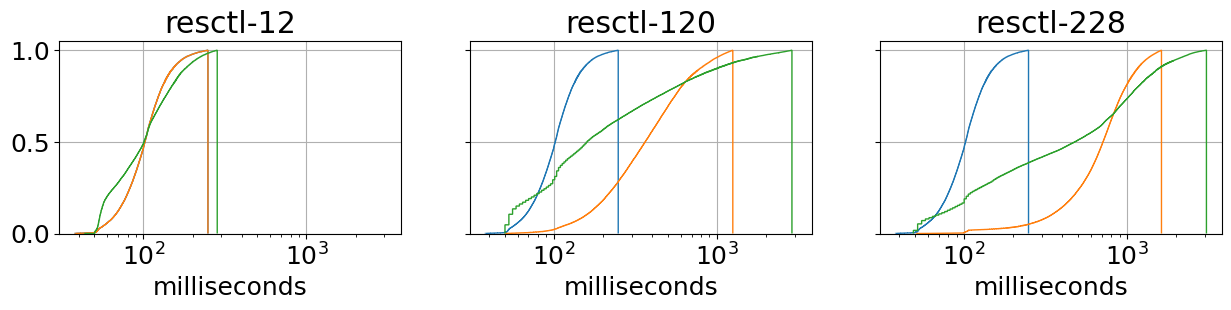

In [55]:


fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_resctlparallel_eevdf_tuned, results_resctlparallel_eevdfllf,fig,ax[0],'resctl-12',12,density=1)
visualise_latency_cdf(results_resctlparallel_eevdf_tuned, results_resctlparallel_eevdfllf,fig,ax[1],'resctl-120',120,density=1)
visualise_latency_cdf(results_resctlparallel_eevdf_tuned, results_resctlparallel_eevdfllf,fig,ax[2],'resctl-228',228,density=1)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,30000)

